# Analisis de telemetría

## Codigo

Pico G (Señal Cruda): 2.96 G
Pico G (Señal Filtrada): 1.27 G


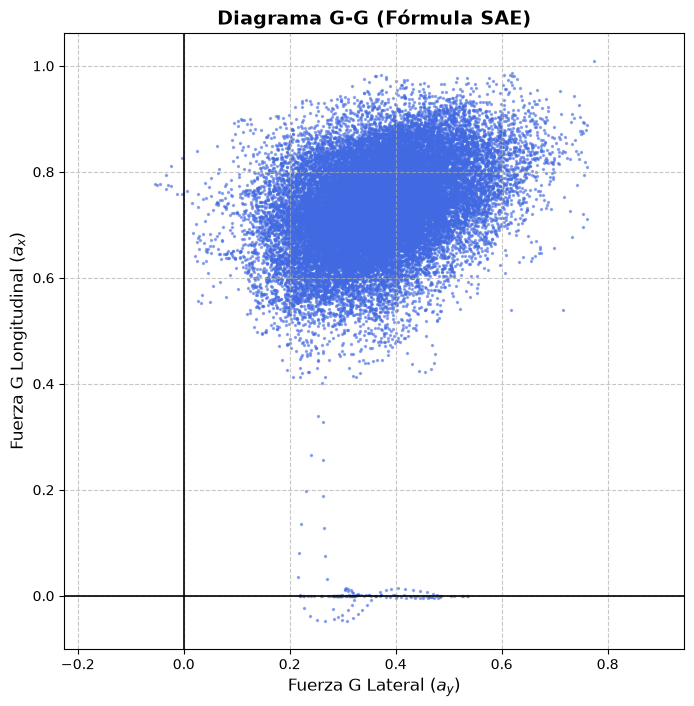

ALERTA: Sensor inercial caído entre los segundos 145.97 y 147.46.
VIOLACIÓN DE PLAUSIBILIDAD! Evento detectado desde 60.11s a 60.4s


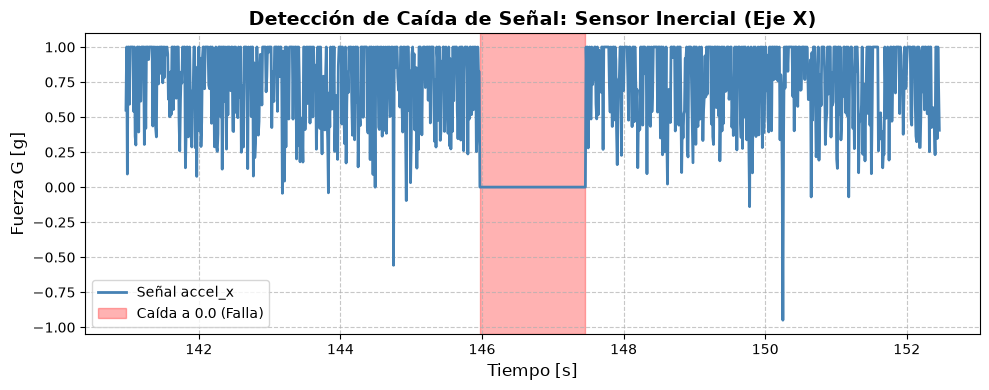

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

df = pd.read_csv("Vanessa Sánchez - data.csv")

# Parámetros
fs = 100
fc = 5
orden = 4
b, a = butter(orden, fc / (0.5 * fs), btype='low', analog=False)

df['accel_x_filt'] = filtfilt(b, a, df['accel_x'])
df['accel_y_filt'] = filtfilt(b, a, df['accel_y'])

df['G_mag_raw'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2)
df['G_mag_filt'] = np.sqrt(df['accel_x_filt']**2 + df['accel_y_filt']**2)

print(f"Pico G (Señal Cruda): {df['G_mag_raw'].max():.2f} G")
print(f"Pico G (Señal Filtrada): {df['G_mag_filt'].max():.2f} G");plt.figure(figsize=(8, 8))

plt.scatter(df['accel_y_filt'], df['accel_x_filt'], alpha=0.5, s=2, color='royalblue')

plt.title("Diagrama G-G (Fórmula SAE)", fontsize=14, fontweight='bold')
plt.xlabel("Fuerza G Lateral ($a_y$)", fontsize=12)
plt.ylabel("Fuerza G Longitudinal ($a_x$)", fontsize=12)
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.show()

falla_inercial = df[df['accel_x'] == 0.0]

t_ini_falla = falla_inercial['Timestamp'].iloc[0]
t_fin_falla = falla_inercial['Timestamp'].iloc[-1]

print(f"ALERTA: Sensor inercial caído entre los segundos {t_ini_falla} y {t_fin_falla}.")

df['plausibility_error'] = (df['brake_pressure'] > 90) & (df['throttle'] > 90)

df['bloque'] = (df['plausibility_error'] != df['plausibility_error'].shift()).cumsum()

bloques_error = df[df['plausibility_error']].groupby('bloque')

for nombre, bloque in bloques_error:
    if len(bloque) > 10:
        t_ini_pps = bloque['Timestamp'].iloc[0]
        t_fin_pps = bloque['Timestamp'].iloc[-1]
        print(f"VIOLACIÓN DE PLAUSIBILIDAD! Evento detectado desde {t_ini_pps}s a {t_fin_pps}s")
        
window_start = max(0, t_ini_falla - 5)
window_end = min(df['Timestamp'].max(), t_fin_falla + 5)
df_window = df[(df['Timestamp'] >= window_start) & (df['Timestamp'] <= window_end)]

plt.figure(figsize=(10, 4))

plt.plot(df_window['Timestamp'], df_window['accel_x'], label='Señal accel_x', color='steelblue', linewidth=2)

plt.axvspan(t_ini_falla, t_fin_falla, color='red', alpha=0.3, label='Caída a 0.0 (Falla)')

plt.title("Detección de Caída de Señal: Sensor Inercial (Eje X)", fontsize=14, fontweight='bold')
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Fuerza G [g]", fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Filtro

### Parametros

In [ ]:
fs = 100
fc = 5
order = 4
b, a = butter(order, fc / (0.5 * fs), btype='low', analog=False)

Se eligió un filtro Butterworth porque ofrece una respuesta de magnitud máximamente plana en la banda de paso. No distorsiona ni amplifica artificialmente las frecuencias bajas que nos interesan.
Ya que con los otros filtros se obtienen estos resutados:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, lfilter

df = pd.read_csv("Vanessa Sánchez - data.csv")

# Parámetros base
fs = 100
fc = 5
orden = 4

# 1. Sin filtro (Crudo)
ax_raw = df['accel_x']
ay_raw = df['accel_y']

# 2. Promedio Móvil (Moving Average) - Ventana de 20 muestras (200ms)
window = 20
ax_ma = df['accel_x'].rolling(window=window, min_periods=1, center=False).mean()
ay_ma = df['accel_y'].rolling(window=window, min_periods=1, center=False).mean()

# 3. Filtro Butterworth Causal (lfilter) 
b, a = butter(orden, fc / (0.5 * fs), btype='low', analog=False)
ax_causal = lfilter(b, a, df['accel_x'])
ay_causal = lfilter(b, a, df['accel_y'])

# 4. Filtro Butterworth Fase Cero (filtfilt)
ax_filtfilt = filtfilt(b, a, df['accel_x'])
ay_filtfilt = filtfilt(b, a, df['accel_y'])

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Comparación de Filtros en Diagrama G-G', fontsize=16, fontweight='bold')

def plot_gg(ax, x, y, title, color):
    ax.scatter(y, x, alpha=0.3, s=2, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Lateral G ($a_y$)', fontsize=10)
    ax.set_ylabel('Longitudinal G ($a_x$)', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axis('equal')
    ax.set_xlim([-3.5, 3.5])
    ax.set_ylim([-3.5, 3.5])

# Graficar
plot_gg(axs[0, 0], ax_raw, ay_raw, '1. Sin Filtro (Crudo)', 'gray')
plot_gg(axs[0, 1], ax_ma, ay_ma, '2. Promedio Móvil (Moving Average)', 'orange')
plot_gg(axs[1, 0], ax_causal, ay_causal, '3. Butterworth Causal (lfilter)', 'red')
plot_gg(axs[1, 1], ax_filtfilt, ay_filtfilt, '4. Butterworth Fase Cero (filtfilt)', 'royalblue')

axs[1, 1].set_xlim([-1, 1])
axs[1, 1].set_ylim([-1, 1.2])

plt.tight_layout()
plt.show()

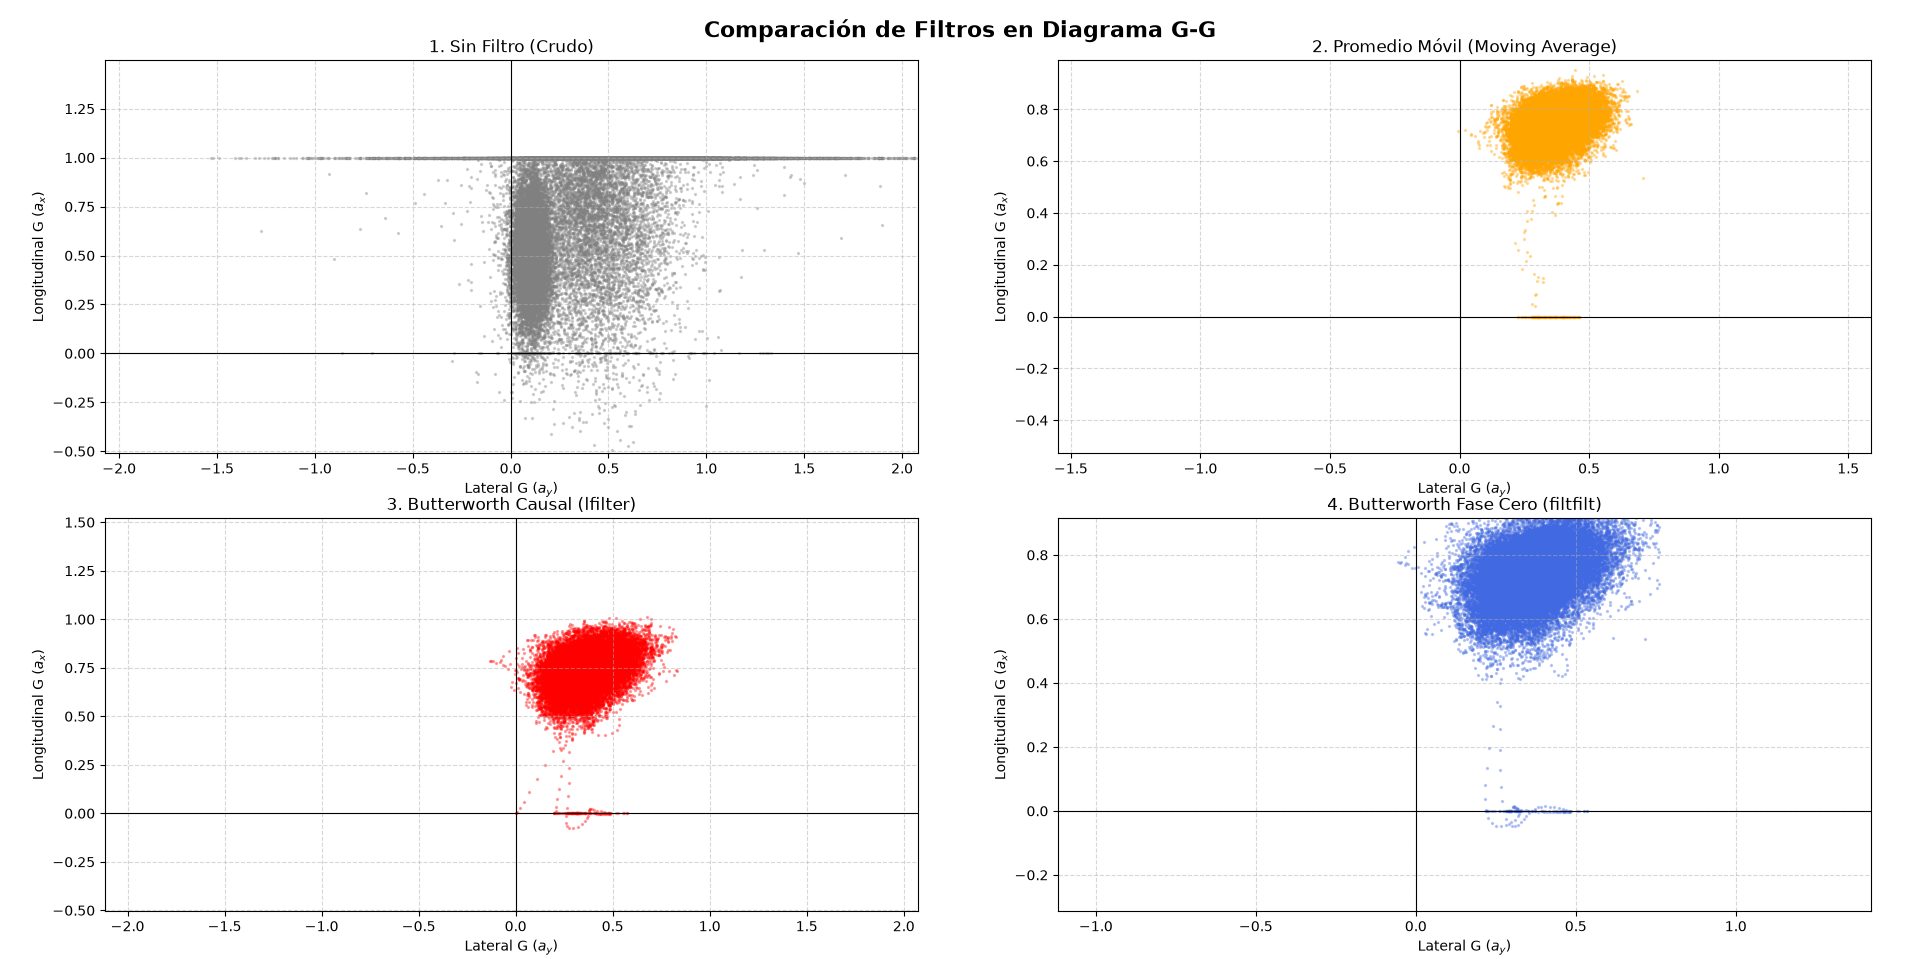

También se a usado en otros estudios para limpiar datos:

    "The simulated pitch angle time signal was digitally filtered
    using a 4th-order Butterworth low-pass filter with a cutoff
    frequency of 0.6 Hz and a sampling rate of 1,000 Hz. The
    simulation signal was processed to be comparable with the
    experimental measurements, as the instrumentation used in
    the sensor fusion process already filters out high frequencies
    from the measured data."

    International Journal of Engineering and Technical Research (IJETR) en: https://www.erpublication.org/published_paper/IJETR3140.pdf, pág. 22

Solo que aquí se usó una frecuencia de corte de 5 Hz para tener un rango medio al limpiar los datos para que el ruido blanco del pavimento y la vibración del motor sea bloqueada (que son de alta frecuencia), también para bloquear el ruido de baja frecuencia como: la transferencia de peso longitudinal al frenar, balanceo de la carrocería en curvas y respuesta de la dirección. Para que solamente quede como resultado la maniobras hechas por el piloto.

    "Generally, the vehicle's highest suspension oscillation frequencies occur below 5 Hz"

    International Journal of Engineering and Technical Research (IJETR) en: https://www.erpublication.org/published_paper/IJETR3140.pdf, pág. 25

Para el orden se uso el de 4to. debido a que un filtro de primer o segundo orden colarian demasiada vibración. Un filtro de cuarto orden da lo suficiente para aislar la señal limpia con rapidez, sin introducir inestabilidad matemática ni efecto campana que a veces generan los filtros excesivamente altos.

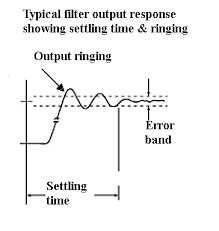

## Valor crudo

El valor crudo no es fiable en la mayoría de materias que usen datos, debido a que contiene mucha información que se capturo con instrumentos muy sensibles que no distinguen unas vibraciones de otras, por eso por ejemplo en la música se usan filtros para aislar la voz del cantante según las frecuencias que cante para que las demás que son captadas como el famoso ruido de fondo sean descartadas para obtener una grabación limpia.

En nuestro caso nuestro cantante que es el piloto y nuestro microfono son los sensores, queremos captar los datos que se generan cuando el piloto maniobra el vehiculo. Para eso ocupamos un filtro que se encarge de remover el ruido de fondo, que en nuestro caso como es mencionado anteriormente son:
* La vibración del motor
* El ruido del asfalto
* La vibración del chasis
* Transferencia de pesos

Los valores crudos no nos ayudan a dar un diagnostico adecuado para ver que problemas tiene el vehiculo o al momento de querer analizarlos no tendrían mucho sentido ya que por ejemplo en el segundo 191.59 se muestra que se llego a una aceleración longitunidal de 2.96 g's, que en un auto de esta indole no llegaría. Al pasar por el filtro se muestra que el verdadero valor es de 1.27 g's, algo más apegado a la realidad.

También afectarían a la hora de ajustar el set-up del vehiculo, si lo ajustas en base a los datos crudos y ves que el pico máximo es de 2.96 ajustarías las suspensiones para una fuerza a la que el vehiculo no va a llegar y se generarían más problemas que soluciones.

## Diagnóstico del diagrama G-G

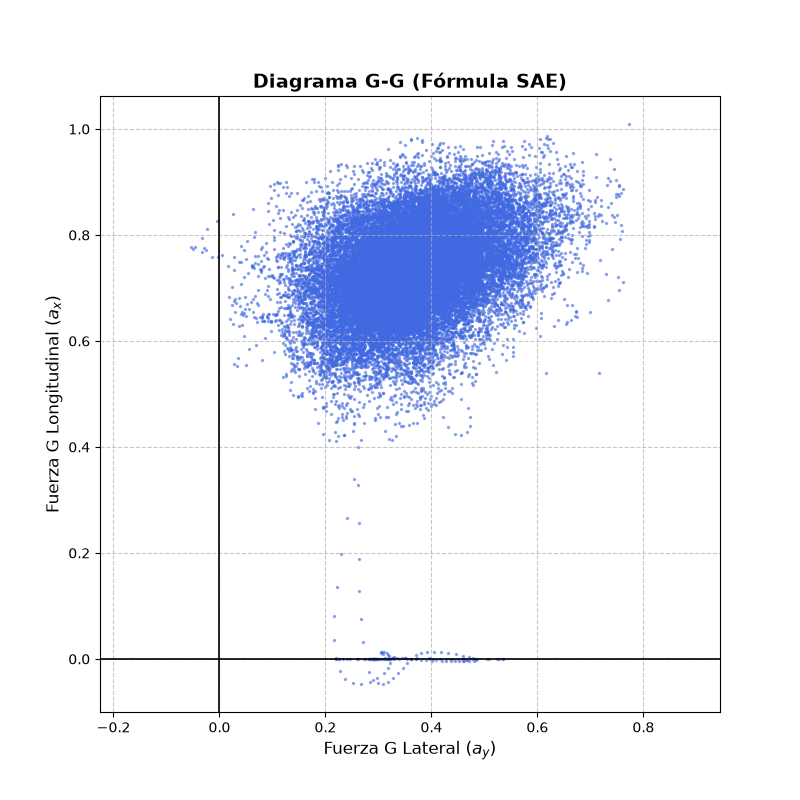

Al analizar el diagrama G-G  con los datos filtrados, se detectó una severa asimetría  direccional en la envolvente de cargas. Los datos se concentran en el cuadrante positivo, mostrando una aparente ausencia total de fuerzas longitudinales de frenado y fuerzas laterales de giro hacia un sentido.

Diagnóstico: Esta anomalía no corresponde a un comportamiento de conducción, Indica un error crítico de los instrumentos, probablemente debido a una Unidad de Medida Inercial (IMU) montada al revés o con un ángulo de inclinación severo, o bien, una saturación del sensor por un desfase de voltaje de corriente continua.

## Detección de Fallas y Seguridad

### **1er. Tipo de anomalía**

Una falla de integridad del hardware en el intervalo de segundo 145.97 al 147.46 debido a una caída al cero absoluto en el canal de aceleración (accel_x), probablemente debido a un cortocircuito temporal, desconexión del cableado o pérdida de paquetes.


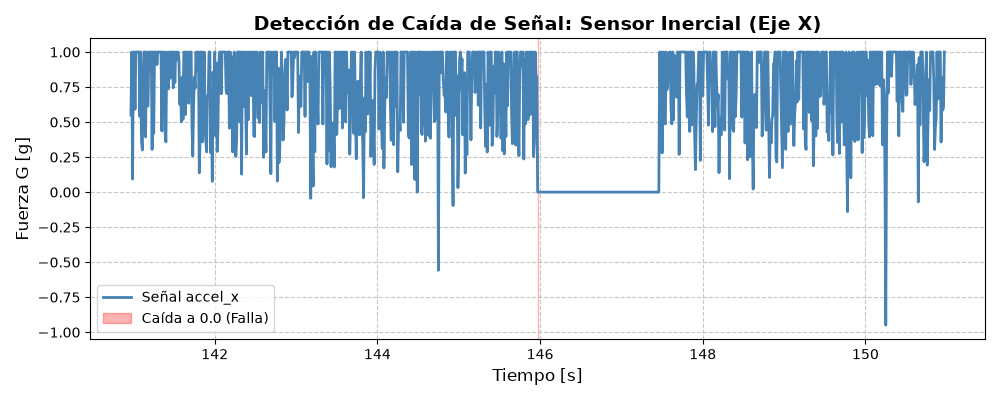

### **2do. Tipo de anomalía**

Una violación en la plausibilidad APPS en el intervalo de tiempo del segundo 60.11 al 60.40 debido a la activacipon simultanea del acelerador y freno fue detectada aplicando una regla estricta de persistencia de menos de 100ms continuos para descartar ruido.


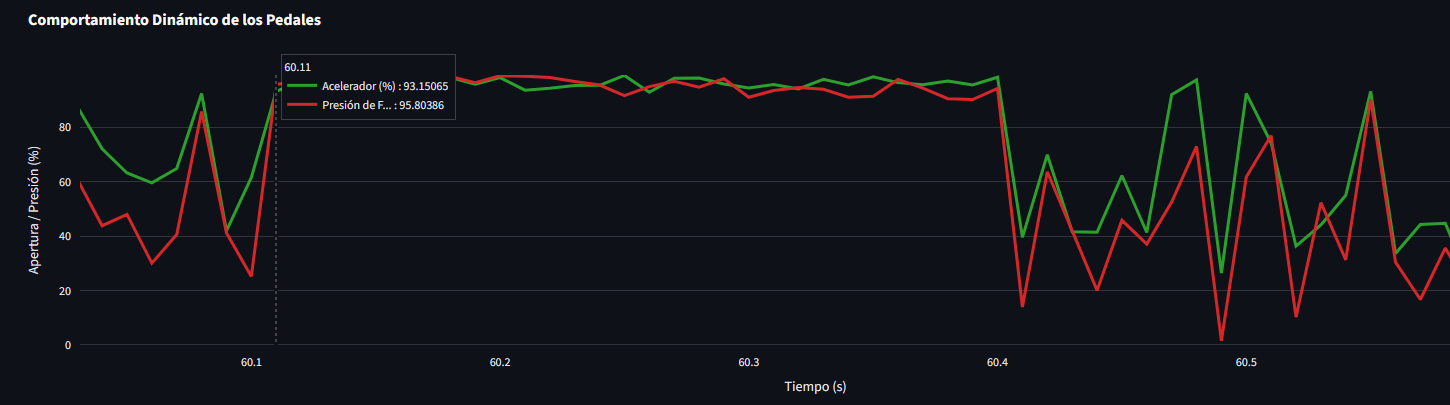

## Recomendaciones
1. Inspección de hardware.
   Revisar el montaje físico de la IMU en el chasís, asegurando su correcta orientación según los ejes coordenados del vehículo.
   
2. Mantenimiento de los arneses.
   Revisar el cableado del sensor inercial para localizar la causa física de la caída de voltaje a cero en el segundo 145.

3. Revisión de seguridad
   Integrar el script de validación APPS directamente en el microcontrolador a bordo para asegurar el corte automático de motor y el estricto
   cumplimiento normativo.


## Investigación
Para respaldar el diagnóstico físico del sensor inercial propuesto en la sección 2, se consultaron discusiones y casos de estudio técnicos dentro de la comunidad de ingeniería de FSAE. Específicamente se tomó como referencia técnica el análisis sobre diagramas de fricción y calibración documentados en:

	Reddit de ingeniería FSAE (G-G Question):
	https://www.reddit.com/r/FSAE/comments/134iykr/gg_diagram_question/
    
La revisión  de este material confirma que una envolvente de cargas fuertemente sesgada a hacía un cuadrante es el síntoma clásico de una IMU mal orientada físicamente o carente	 de una correcta compensación de DC bias. Esto valida matemáticamente la conclusión obtenida en nuestro análisis de datos e invalida el uso del registro crudo para simulaciones de dinámica vehicular.
